# Title: Introduction to Logistic Regression
## Date: 02/27/2024
## Author: Gary Mitchell
___

# What is logistic regression?

Logistic regression is a model building approach that allows us to calculate the *probability* of an event occurring rather than the value of the event as in least squares (or linear) regression. Logistic regression is useful for performing *classification*.

I prepared this document using Jupyter Notebook which allows me to incorporate my code, discussion, and output (including charts and graphs) in a single document. Don't worry about any of the Python code in the document. I'll give brief explanations, but you are absolutely *not* required to learn any of this code (one programming language per course is enough I think...). If you're interested in learning Python or Machine Learning, you may be interested in taking the following:

- BUS 549 - Python for Business and Analytics (Fall) - learn sound programming fundamentals while developing the basic skills needed for coding business analysis and analytics in Python
- BUS 554 - Applied Machine Learning - learn the fundamentals of machine learning, including multiple nethods in classification (e.g. support vector machines, naive Bayes, decision trees, random forests), regression (support vector machines, decision trees, random forests), reinforcement learning, and an introduction to deep learning with artificial neural networks. Requires BUS 549 (or instructor permission).

## We need data
All machine learning (and logistic regression, along with least squares regression, are machine learning algorithms) require data. Generally, lots and lots of data.

To illustrate the use of logistic regression in classification, we will utilize a well-known dataset containing data on 699 tumors (breast cancer). Our goal will be to develop a model that can reliably diagnose whether a tumor is malignant or benign. 699 observations is a *small* dataset for machine learning, but I think this is an application that everyone can understand, and possibly relate to. Cancer of various kinds affects *so* many of us, either directly or indirectly. Estimates vary between 1 in 12 and 1 in 4 people will be diagnosed with some form of cancer in their lifetimes...

# Getting started
What makes Python a de facto standard for machine learning isn't Python, it's the many excellent packages that are available from within Python (most are actually written in C/C++ for speed, but offer a Python interface). The following code simply loads a number of packages for our demo.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression


The dataset we're working with is a fairly old dataset. Consequently, the data is stored without column labels. To address this, we'll programmically generate the column names; for each attribute (e.g., radius), we have 3 metrics (mean, standard error, and worst).

In [5]:
from itertools import product

attrib = ['radius',
          'texture',
          'perimeter',
          'area',
          'smoothness',
          'compactness',
          'concavity',
          'concave_points',
          'symmetry',
          'fractal_dimension']

metrics = ['mean', 'se', 'worst']

attrib_names = [f'{r[0]}_{r[1]}' for r in product(attrib, metrics)]
colnames = ['id', 'class']
colnames = colnames + attrib_names
print(colnames)


['id', 'class', 'radius_mean', 'radius_se', 'radius_worst', 'texture_mean', 'texture_se', 'texture_worst', 'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'area_mean', 'area_se', 'area_worst', 'smoothness_mean', 'smoothness_se', 'smoothness_worst', 'compactness_mean', 'compactness_se', 'compactness_worst', 'concavity_mean', 'concavity_se', 'concavity_worst', 'concave_points_mean', 'concave_points_se', 'concave_points_worst', 'symmetry_mean', 'symmetry_se', 'symmetry_worst', 'fractal_dimension_mean', 'fractal_dimension_se', 'fractal_dimension_worst']


Now we use Pandas, a standard in the Python ecosystem for data management/manipulation, to create a DataFrame (it's like an R data frame on steroids), adding the column names. Note the *header=None* argument. The sample below shows our dataset. We see that each observation has a *class* (i.e., diagnosis). This is our dependent variable and, in machine learning, is referred to as a label; labels are the *actual* outcomes.

In [6]:
wibc_real = pd.read_csv('wdbc.data', header=None, names=colnames)
wibc_real.head()

,id,class,radius_mean,radius_se,radius_worst,texture_mean,texture_se,texture_worst,perimeter_mean,perimeter_se,...,concavity_worst,concave_points_mean,concave_points_se,concave_points_worst,symmetry_mean,symmetry_se,symmetry_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Visualizing our data

We have 30 total features (independent variables), which would be a lot to graph. So, let's generate column names for only the *mean* features. We'll then use these column names to select a subset of features (means in this case) for graphing.

In [7]:
mean_cols = wibc_real.columns[[True if re.search('mean$', c) else False for c in wibc_real.columns]]
mean_cols

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean'],
      dtype='object')

To facilitate our graphing task, we'll create *benign* and *malignant* subsets of the data.

In [8]:
grps = wibc_real.groupby('class')
benign = grps.get_group('B')
malignant = grps.get_group('M')


The graphs which follow illustrate the difference between allowing *unmatched* scales and matching the scales in the plots. The unmatched sales histograms can be misleading, because we do not see the paired (benign and malignant) plots with consistent scales. The matched scale histograms do a much better job of providing insight into the possible differences between the benign and malignant samples.

Text(0.5, 0.98, 'texture_mean - Matched Bins')

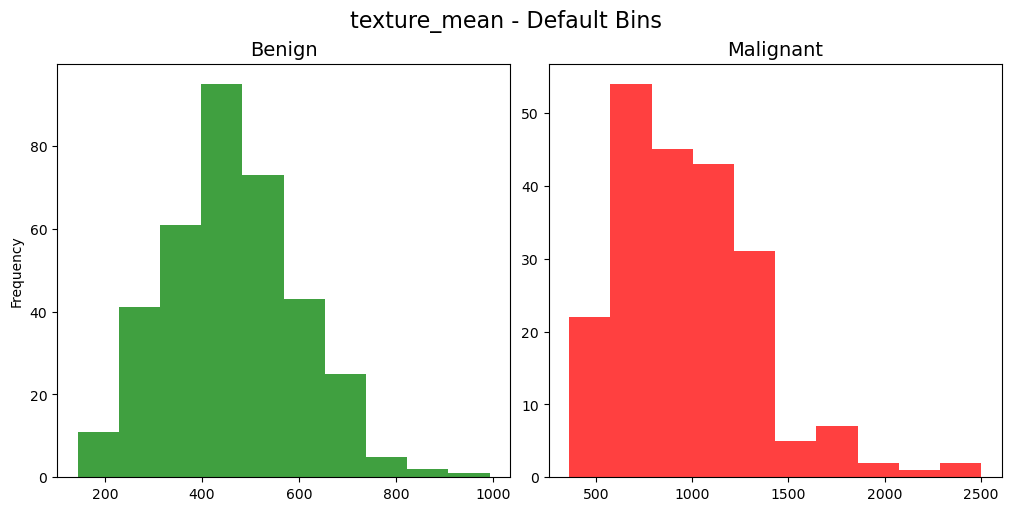

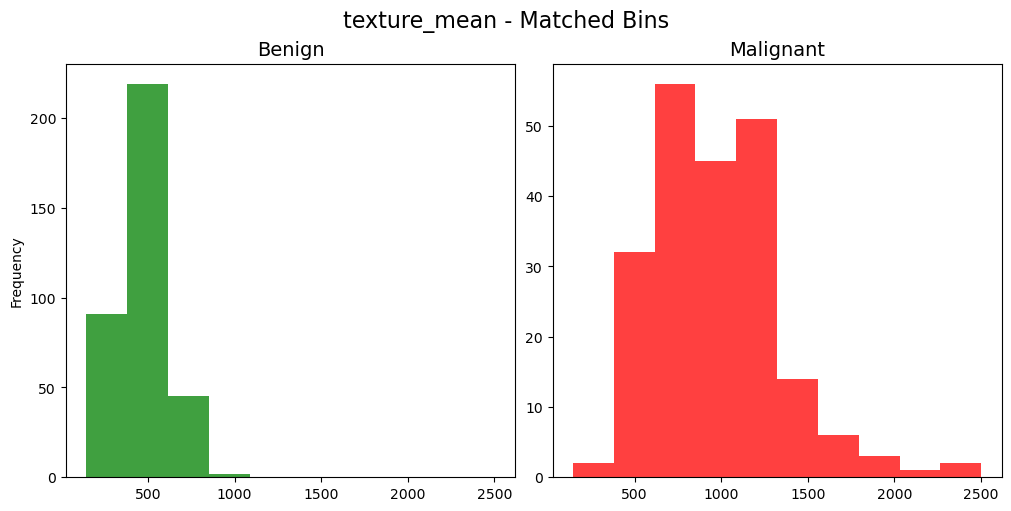

In [9]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5), constrained_layout=True)
c = 'texture_mean'

lb = min(benign[c].min(), malignant[c].max())
ub = max(benign[c].max(), malignant[c].max())
r = 1

ax[0].hist(benign[c], color='green', alpha=0.75)
ax[0].set_ylabel('Frequency')
ax[0].set_title('Benign', fontsize=14)
ax[1].hist(malignant[c], color='red', alpha=0.75)
ax[1].set_title('Malignant', fontsize=14)
plt.suptitle(f'{c} - Default Bins', fontsize=16)

r = 0

fig, ax = plt.subplots(1, 2, figsize = (10, 5), constrained_layout=True)
ax[0].hist(benign[c], bins=10, range=(lb, ub), color='green', alpha=0.75)
ax[0].set_ylabel('Frequency')
ax[0].set_title('Benign', fontsize=14)
ax[1].hist(malignant[c], bins=10, range=(lb, ub), color='red', alpha=0.75)
ax[1].set_title('Malignant', fontsize=14)
plt.suptitle(f'{c} - Matched Bins', fontsize=16)


Now we'll produce the side-by-side histograms for all of the *mean* features:

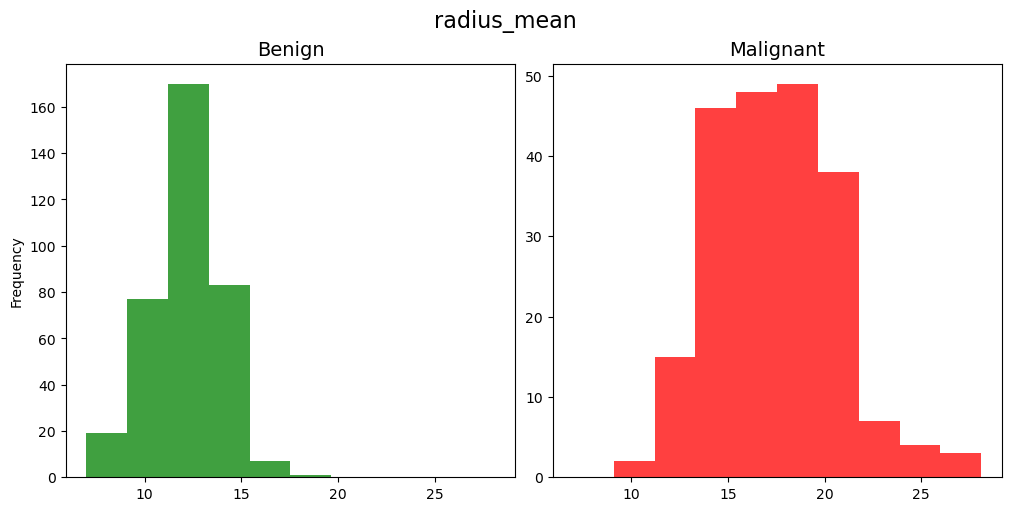

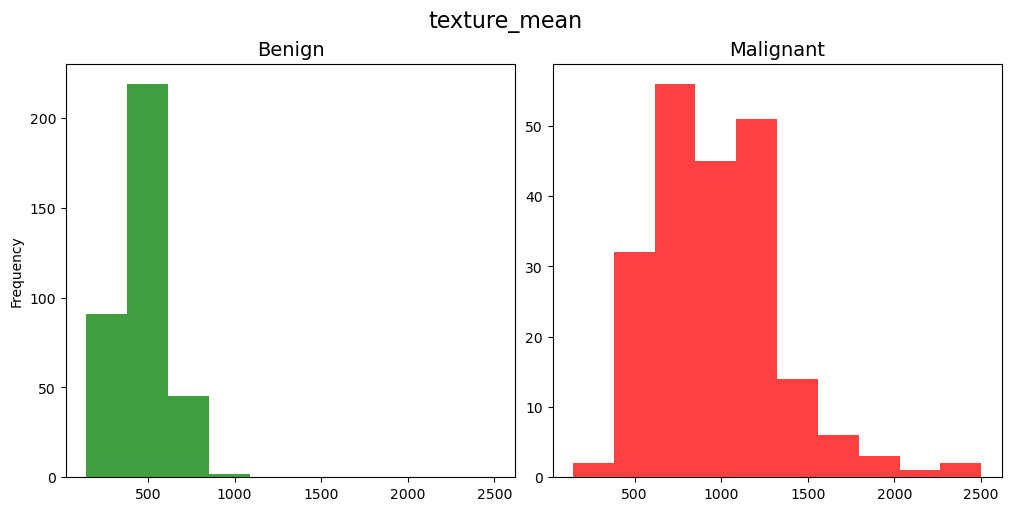

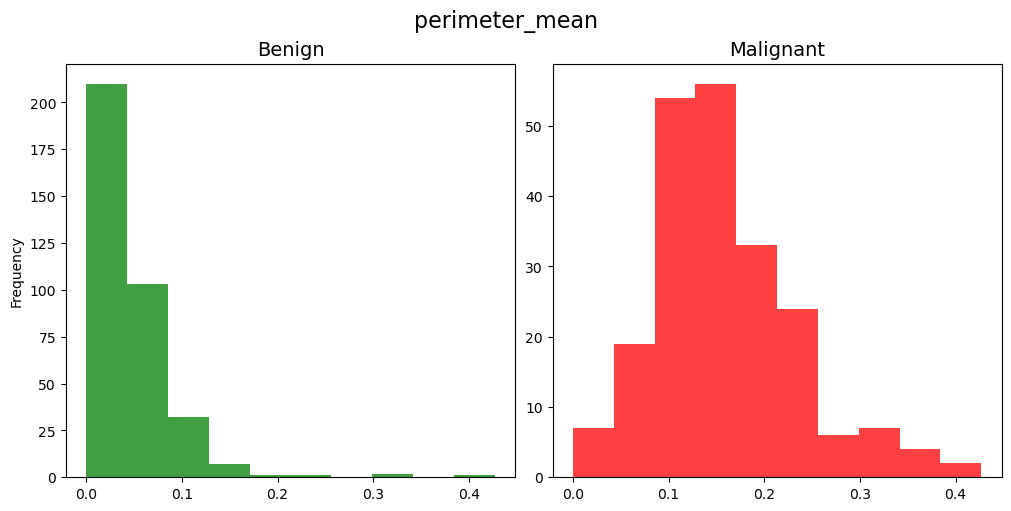

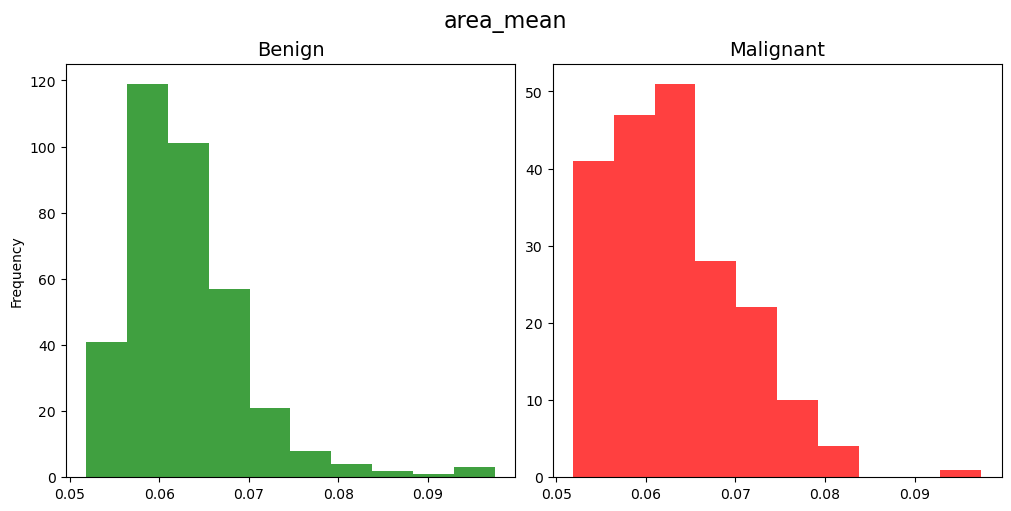

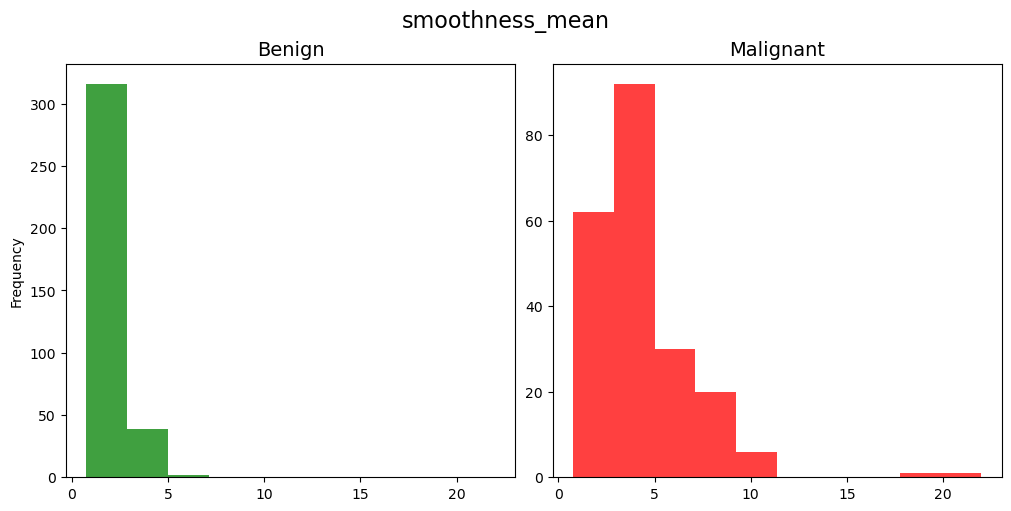

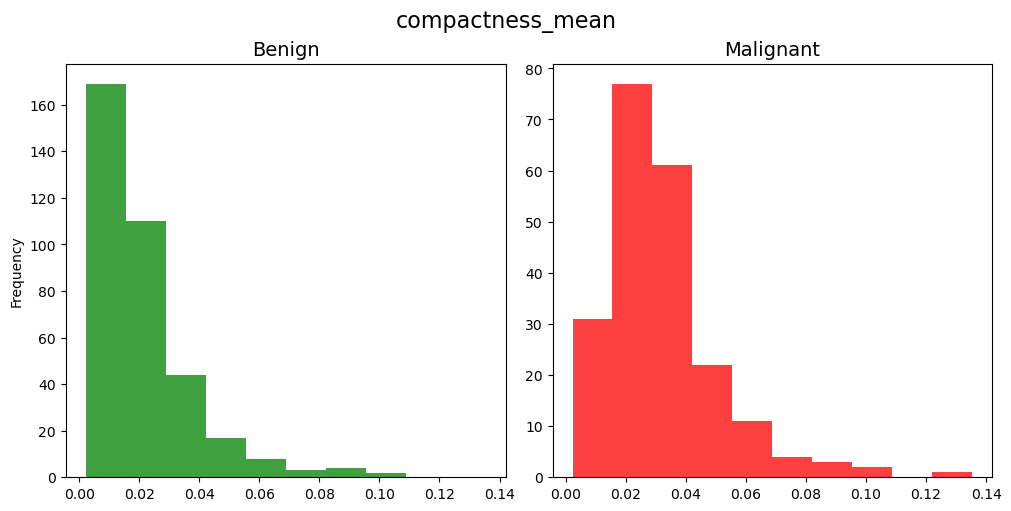

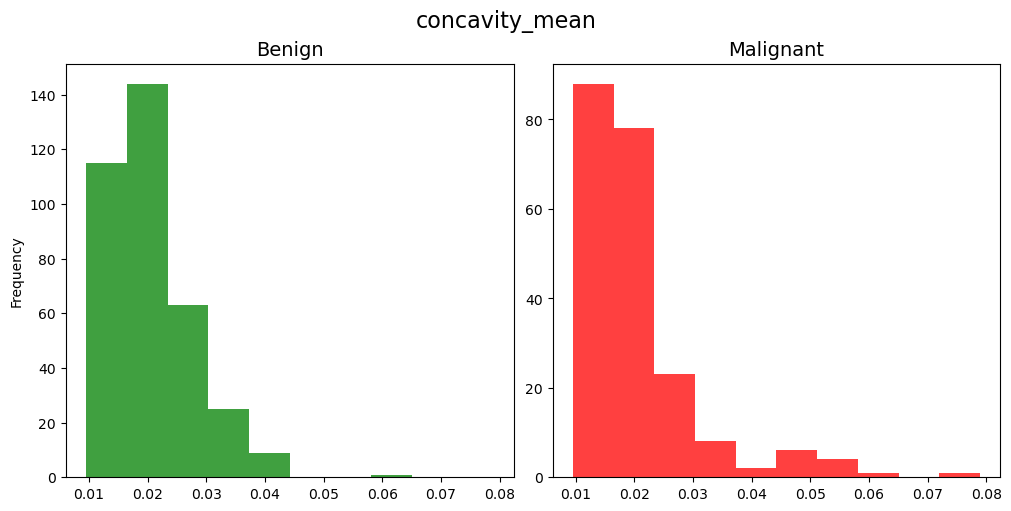

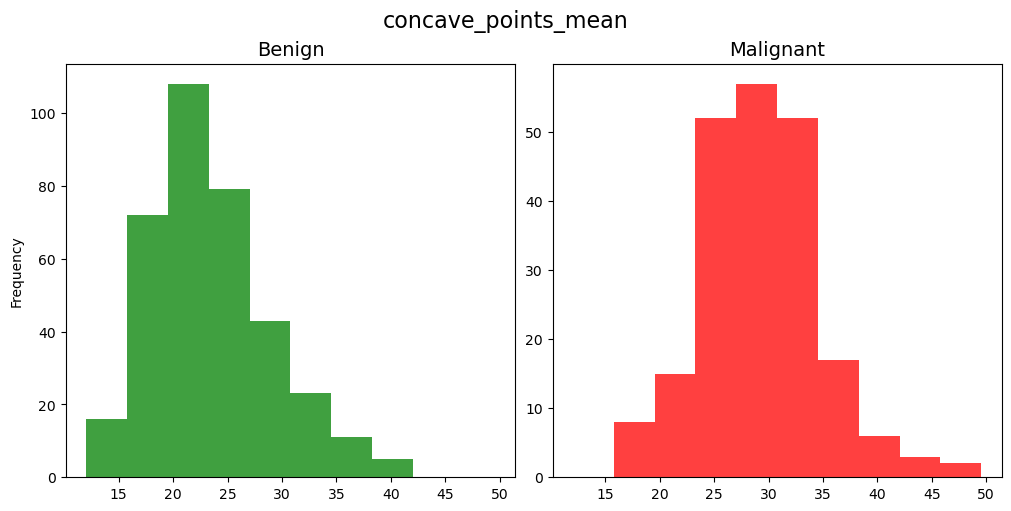

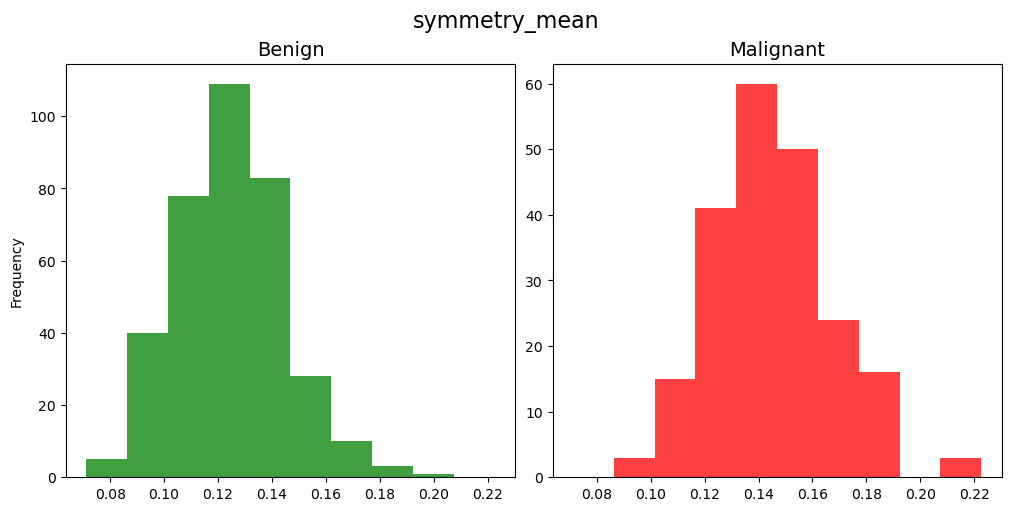

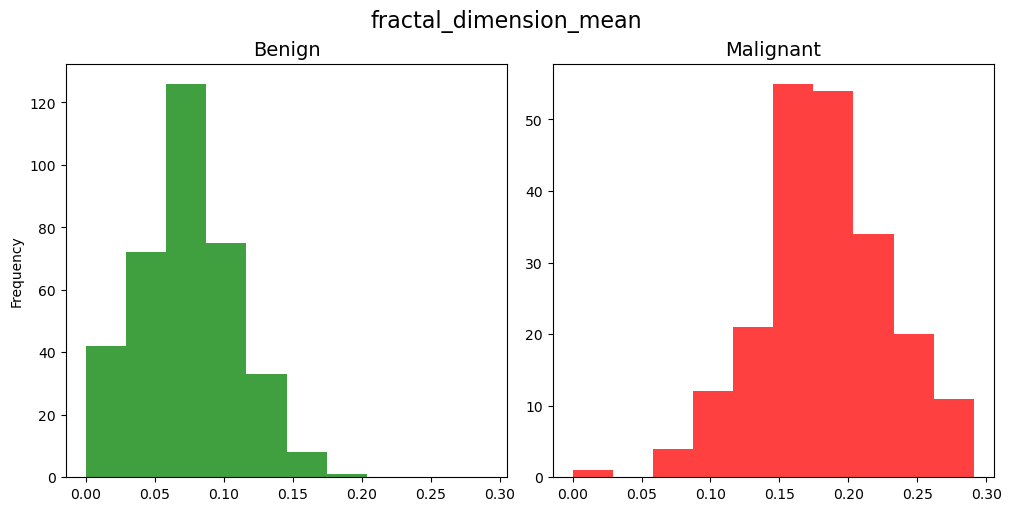

In [10]:
for c in mean_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
    lb = min(benign[c].min(), malignant[c].max())
    ub = max(benign[c].max(), malignant[c].max())
    ax[0].hist(benign[c], bins=10, range=(lb, ub), color='green', alpha=0.75)
    ax[0].set_ylabel('Frequency')
    ax[0].set_title('Benign', fontsize=14)
    ax[1].hist(malignant[c], bins=10, range=(lb, ub), color='red', alpha=0.75)
    ax[1].set_title('Malignant', fontsize=14)
    plt.suptitle(c, fontsize=16)

The graphs below provide a visualization for the three metrics *within* a feature. These scatterplots color the observation markers by diagnosis/class (green for benign, red for malignant). 

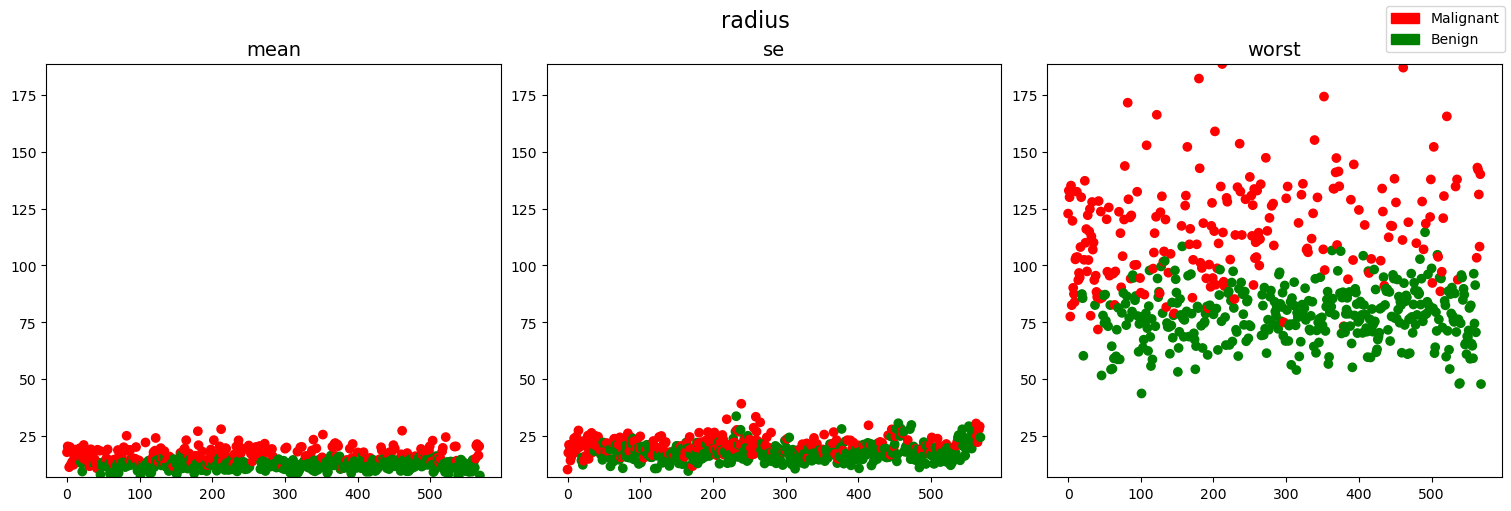

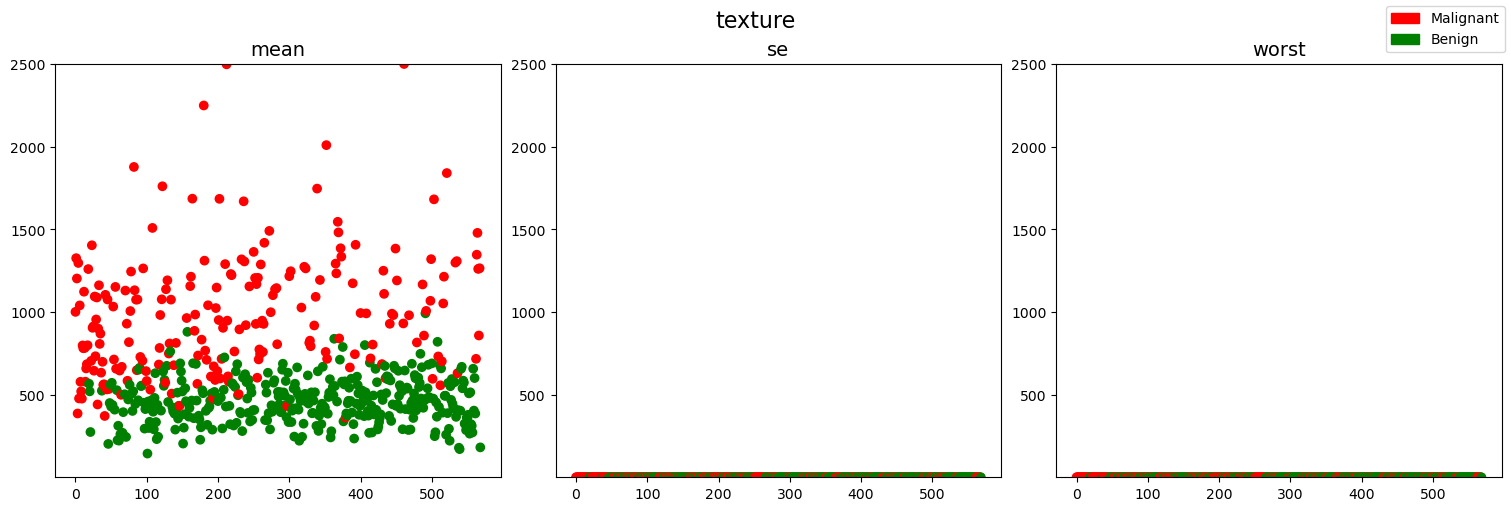

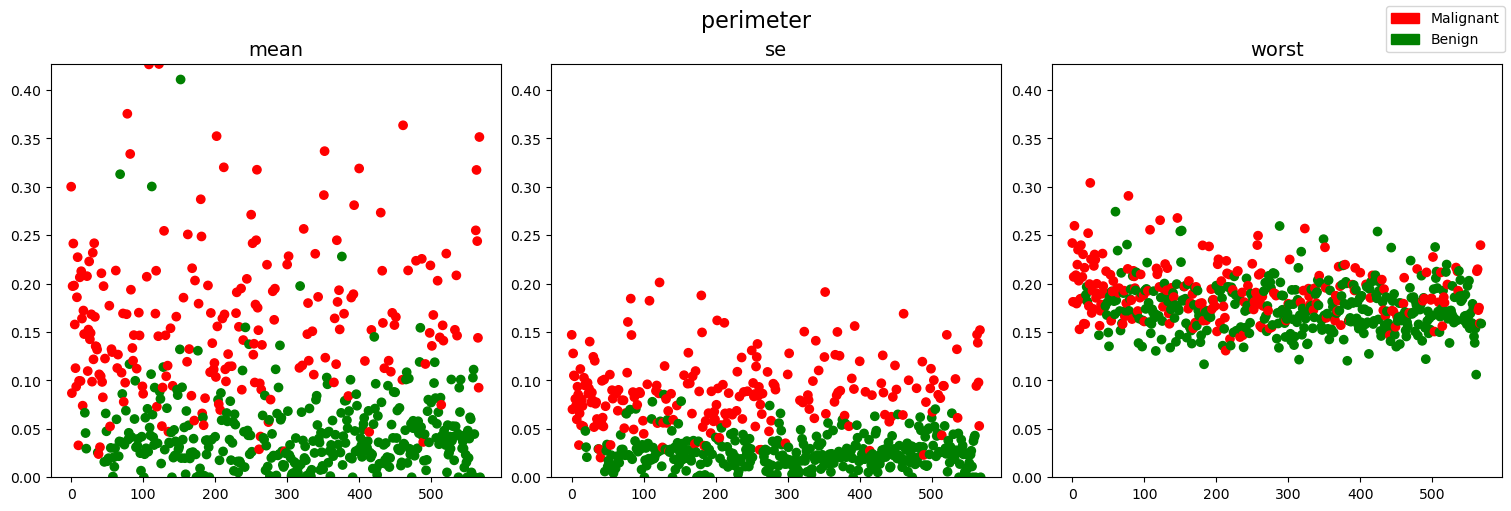

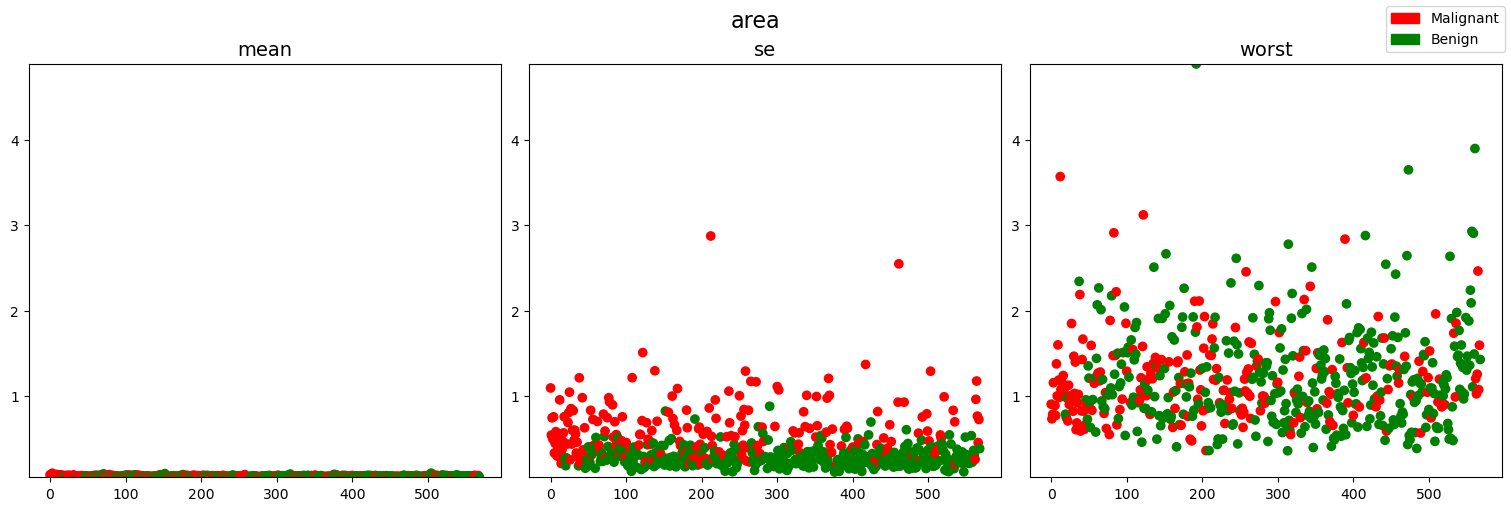

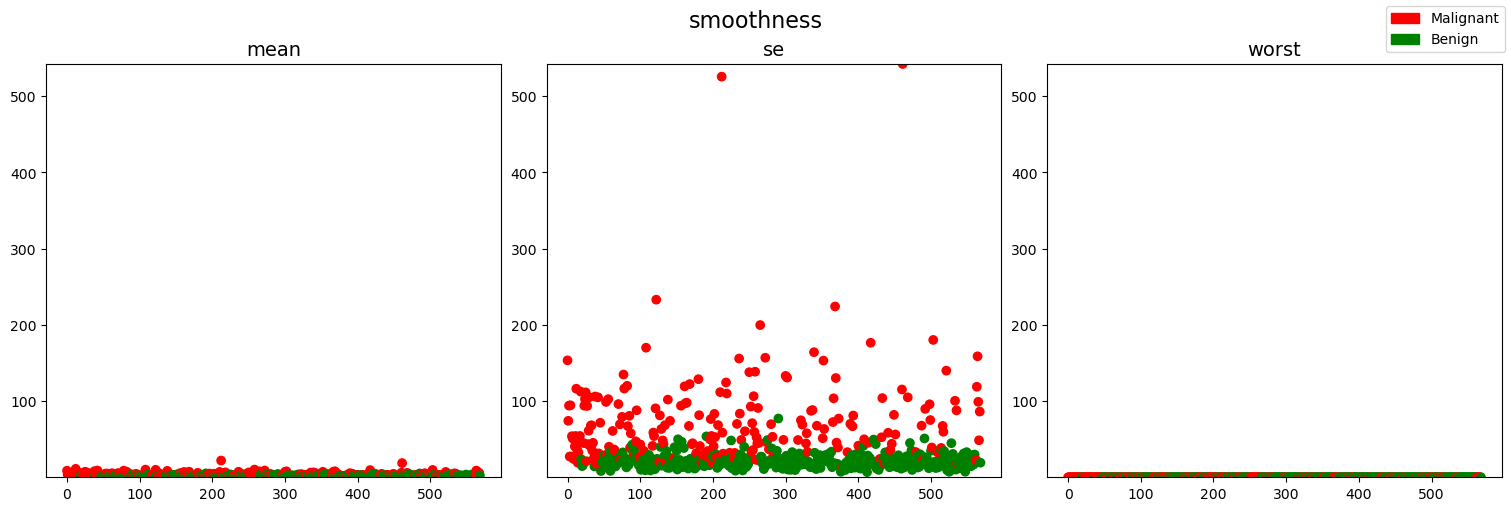

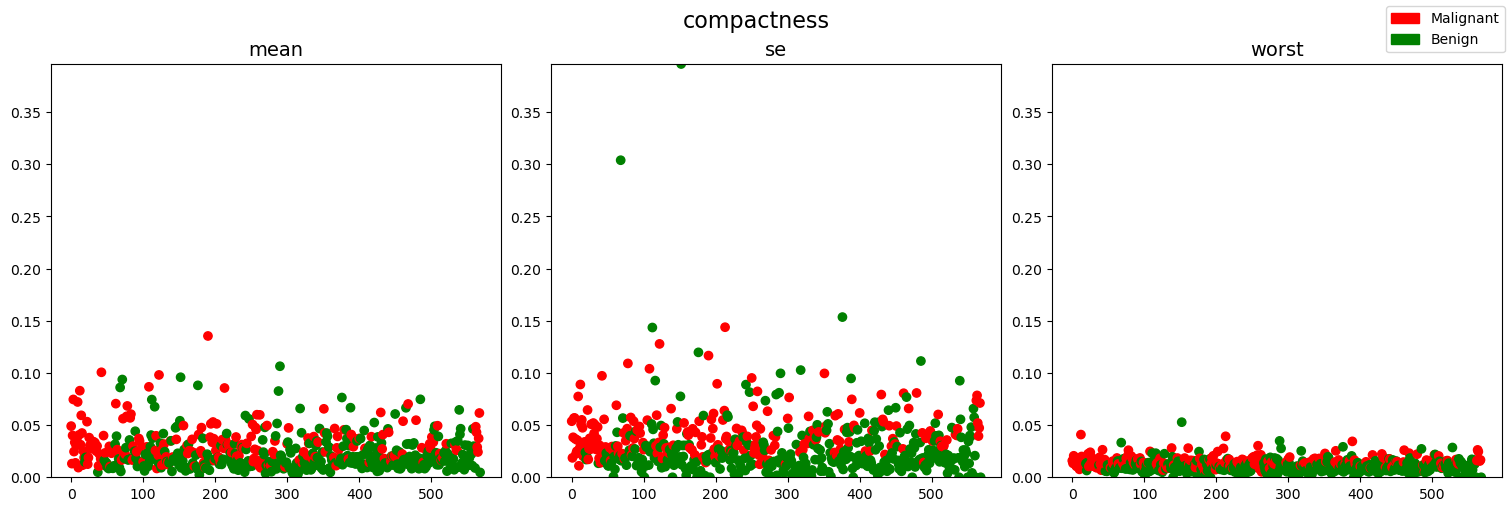

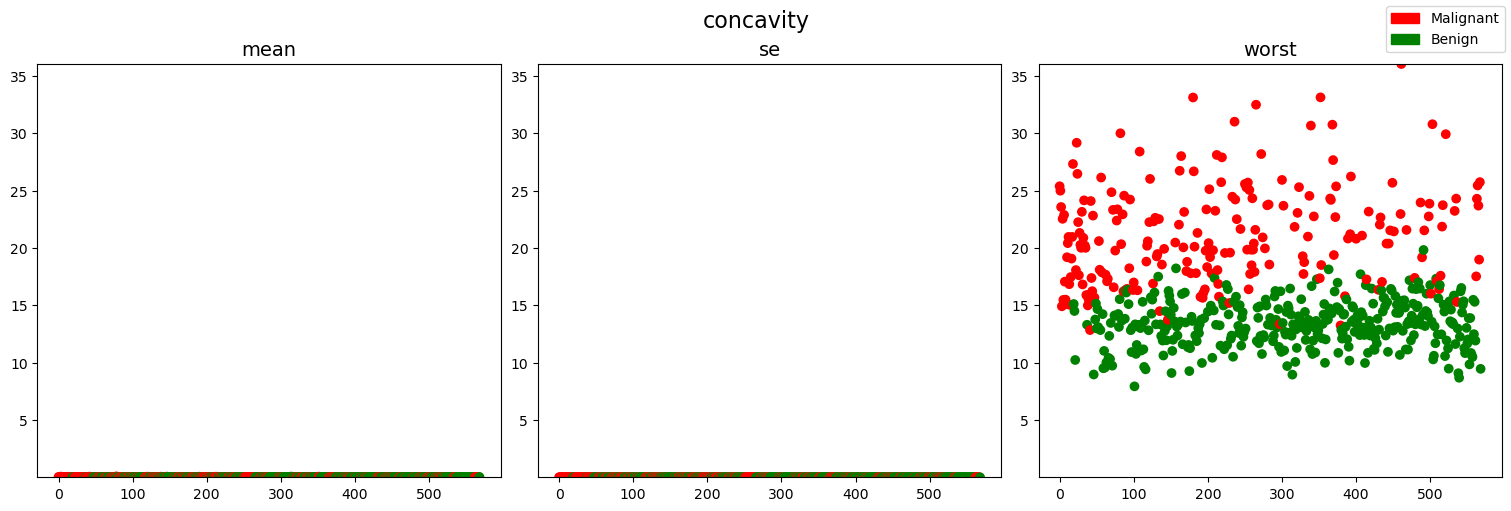

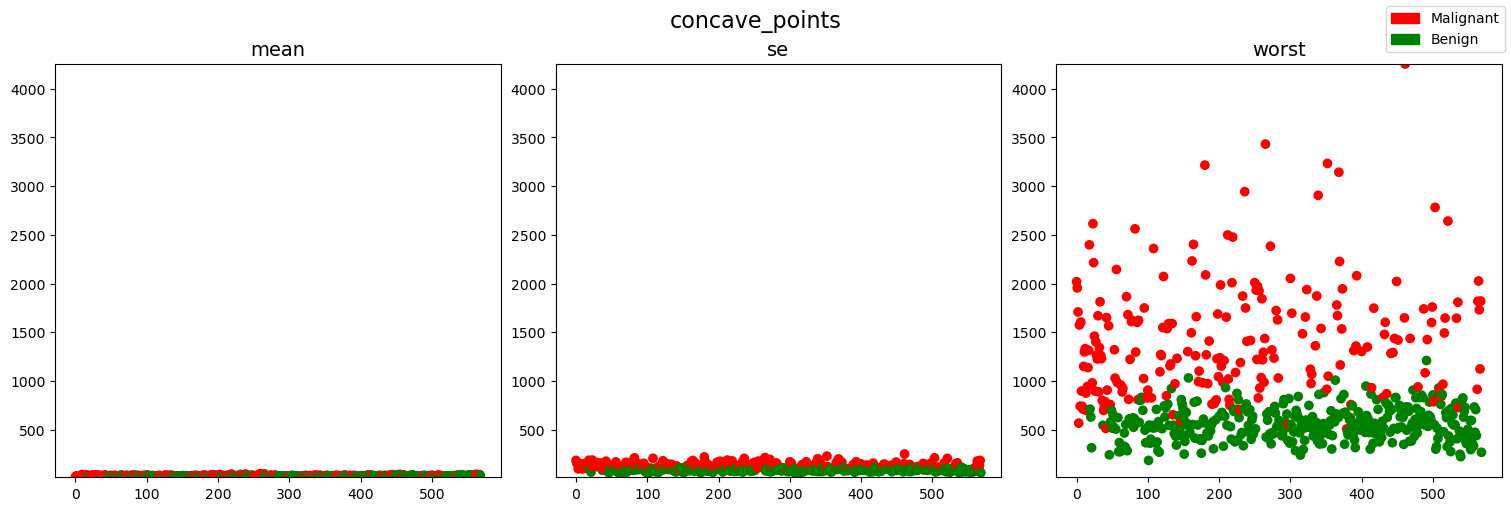

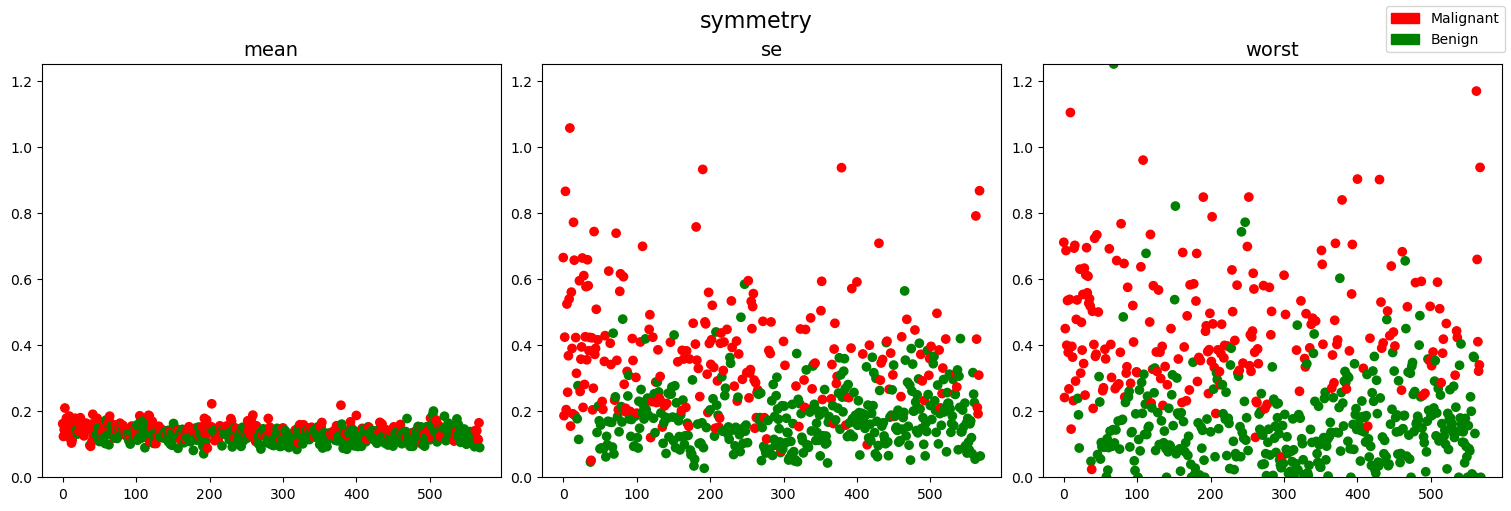

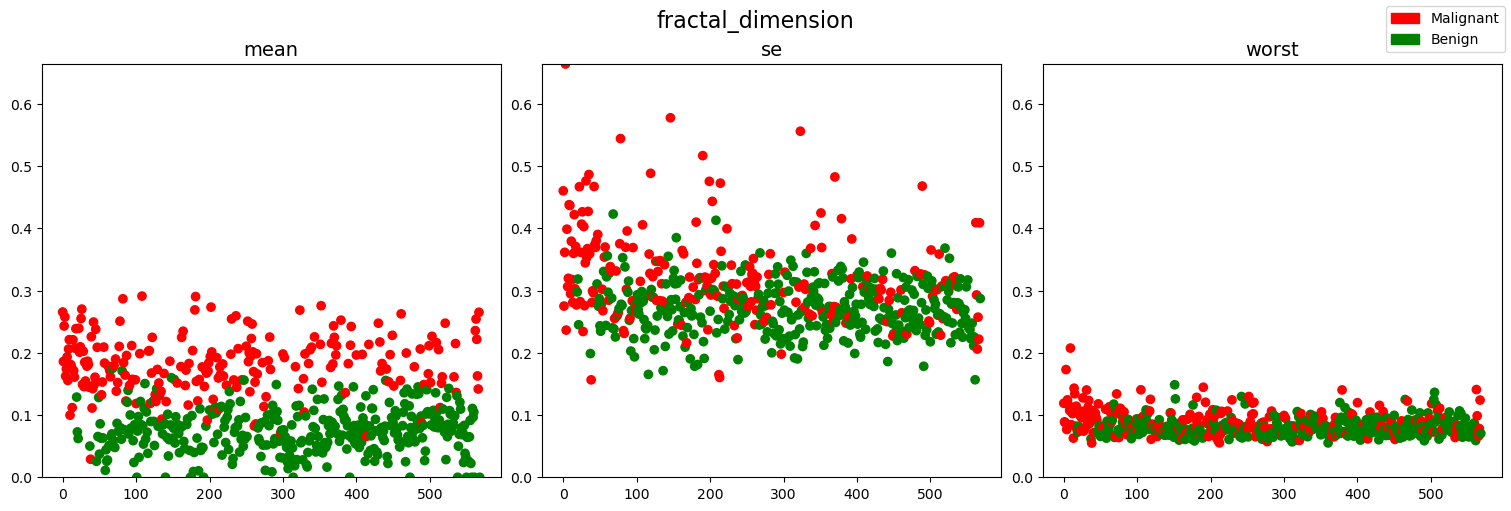

In [11]:
colors = np.array(['r', 'g'])[wibc_real['class'].factorize()[0]]

for c in attrib:
    i = -1
    lb = min([wibc_real[f'{c}_{m}'].min() for m in metrics])
    ub = max([wibc_real[f'{c}_{m}'].max() for m in metrics])
    
    fig, ax = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True)
    for cm in [f'{c}_{m}' for m in metrics]:
        i += 1
        ax[i].set_ylim(lb, ub)
        ax[i].scatter(wibc_real.index, wibc_real[cm], c=colors)
        ax[i].set_title(metrics[i], fontsize=14)
        
    fig.suptitle(c, fontsize=16)
    
    red_patch = mpatches.Patch(color='red', label='Malignant')
    green_patch = mpatches.Patch(color='green', label='Benign')
    fig.legend(handles=[red_patch, green_patch])    

We noted some serious scale issues across the features, which will likely have a negative impact on any models we attempt to fit on the data. Now, let's look at the results of applying a StandarScalar:

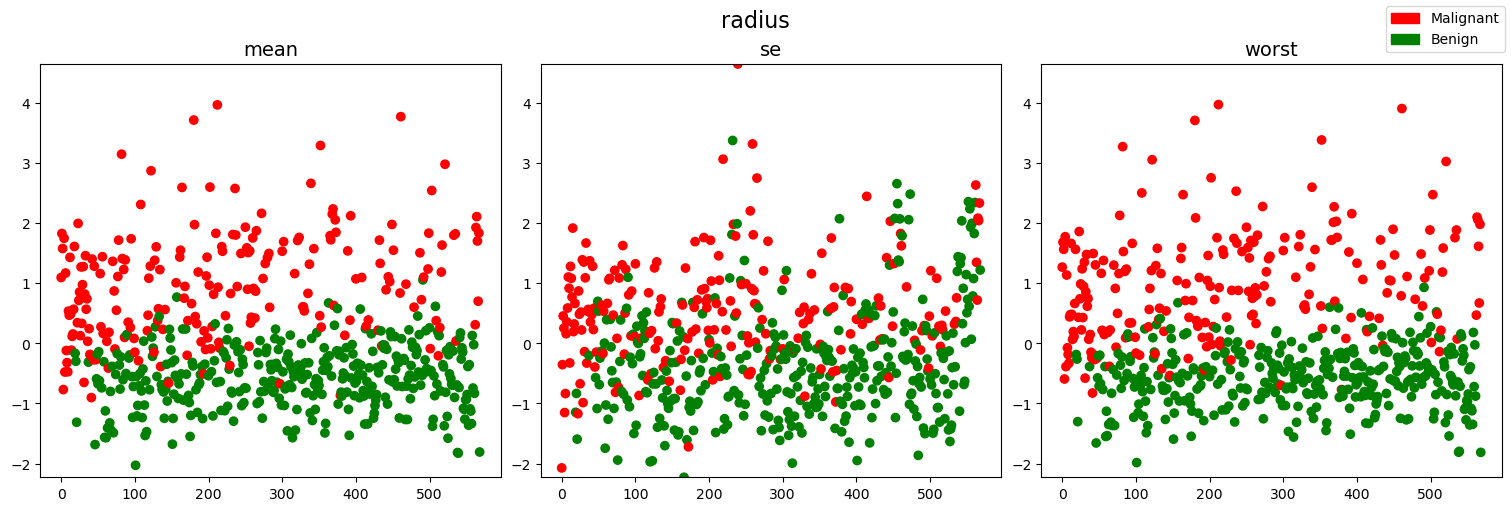

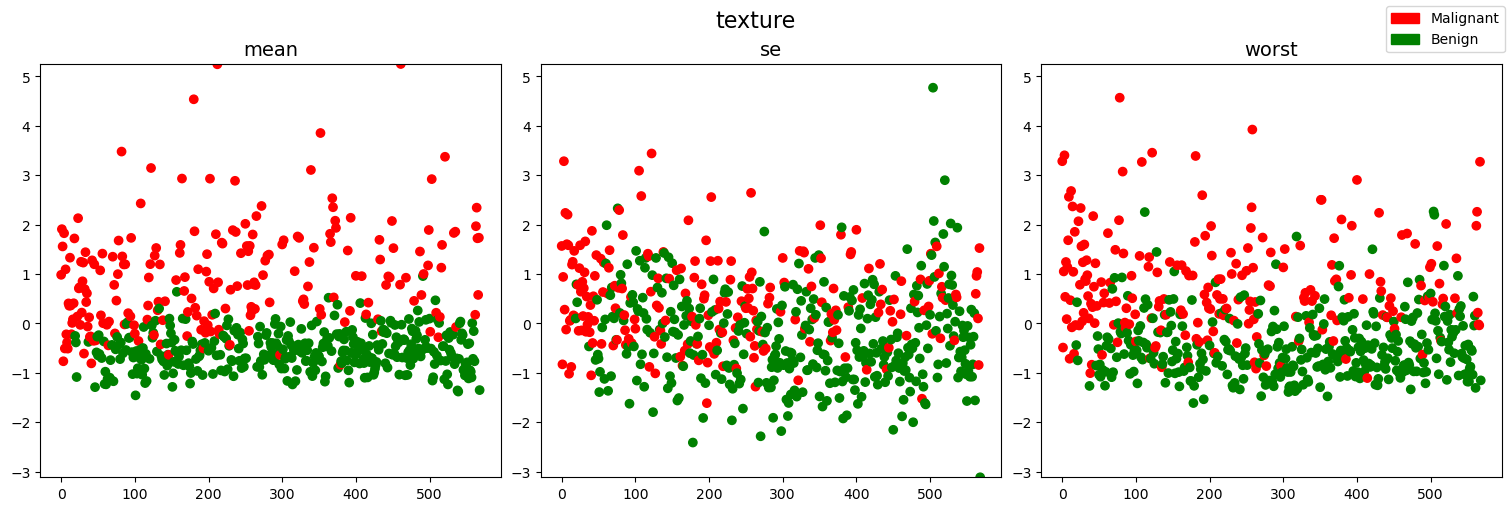

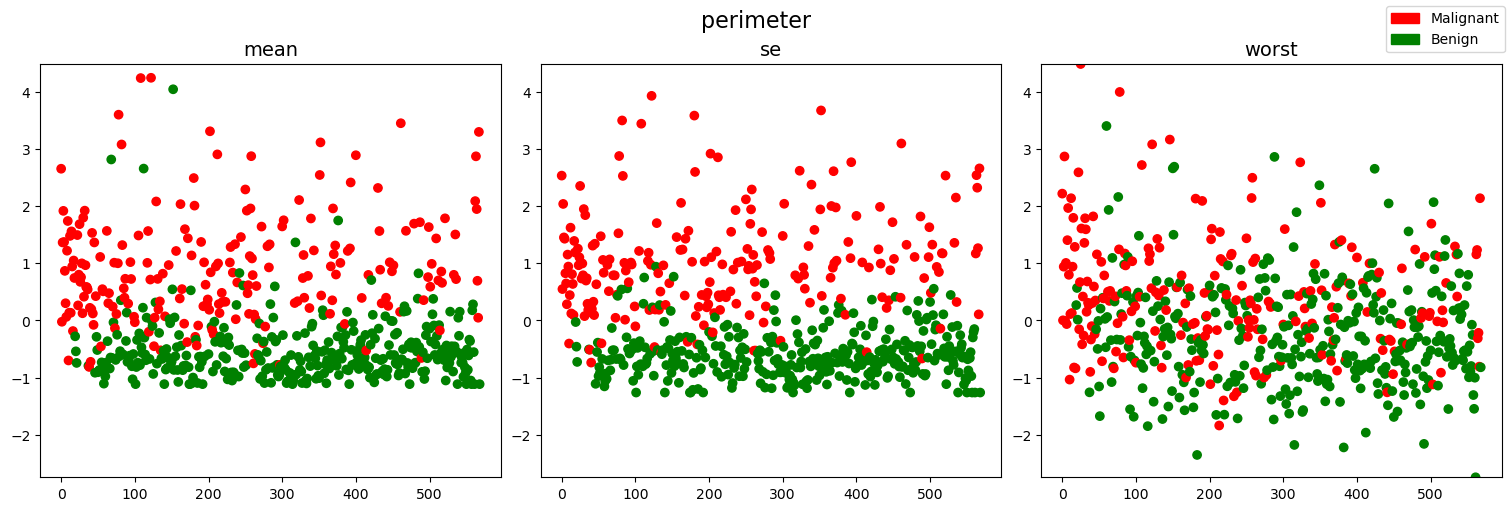

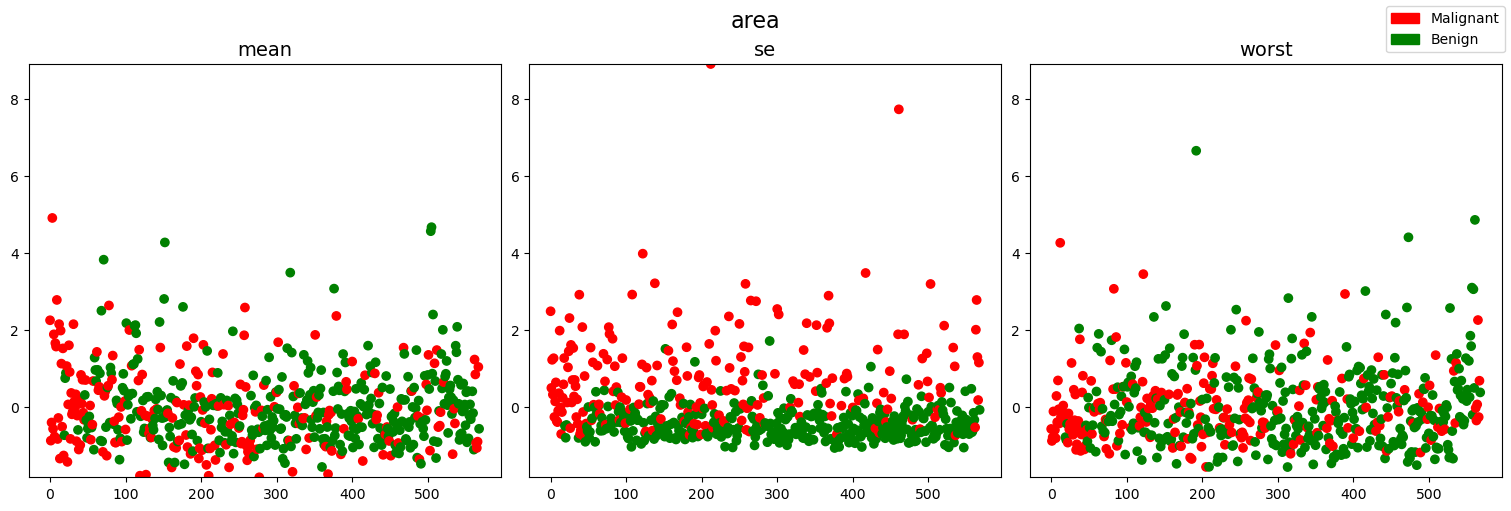

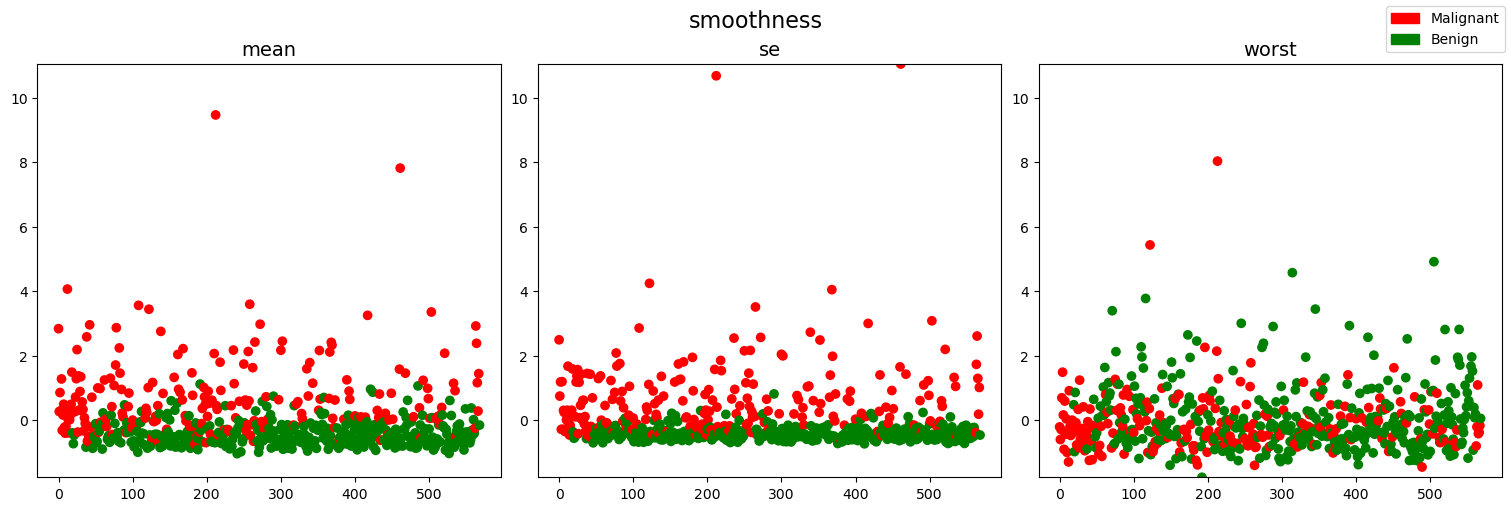

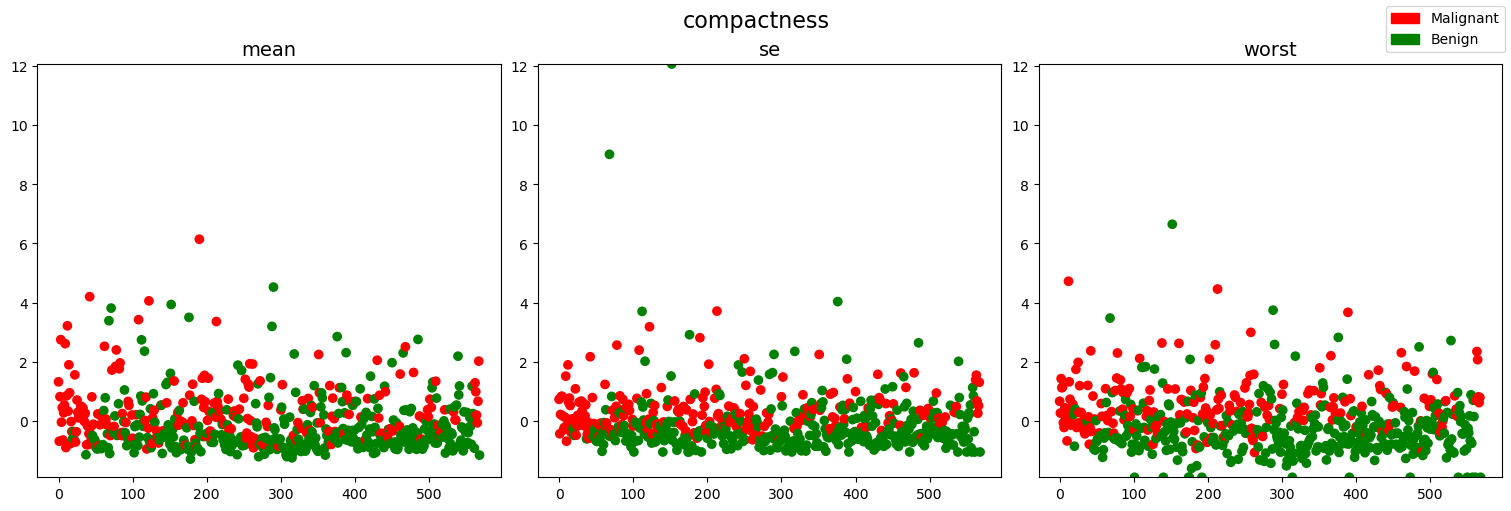

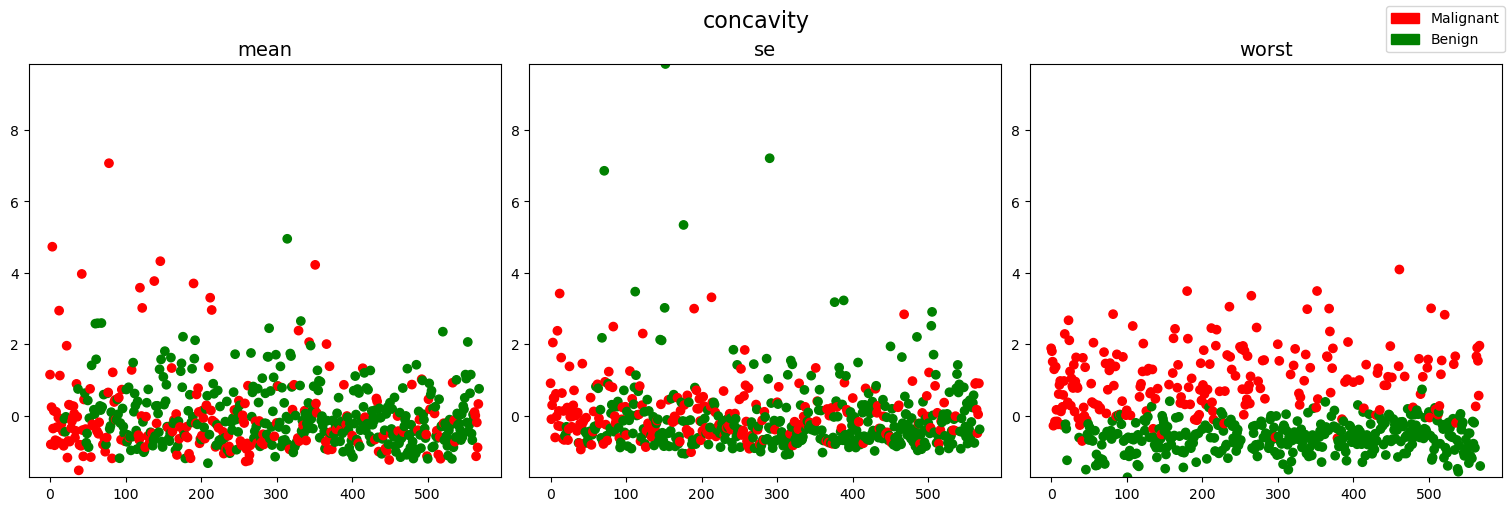

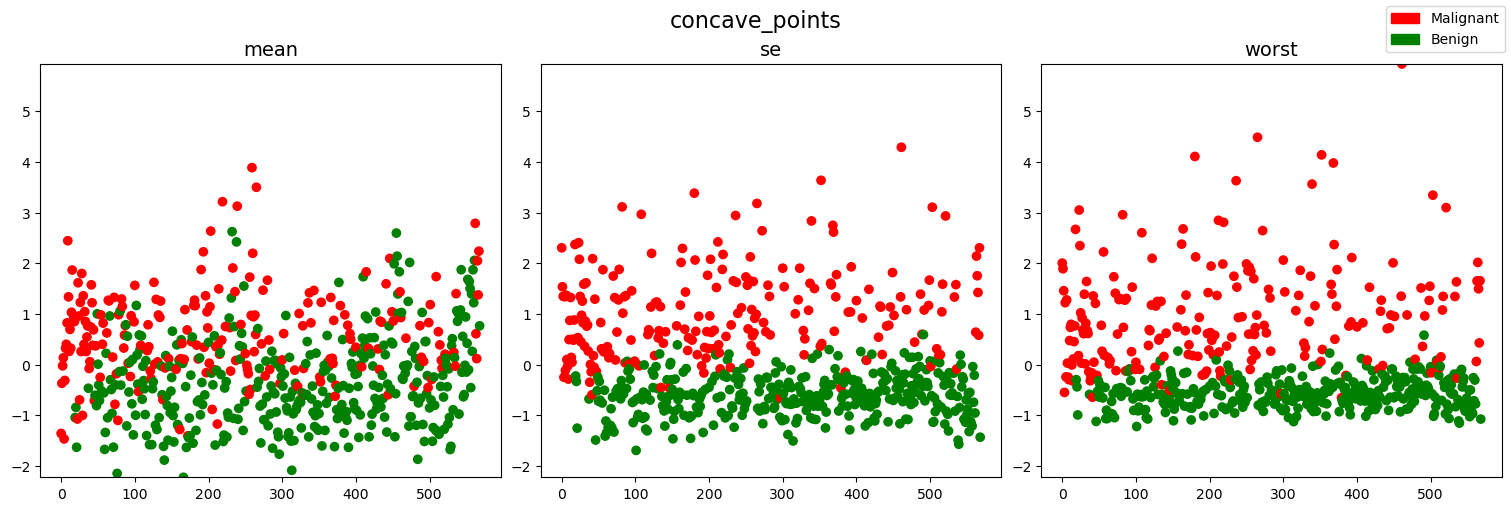

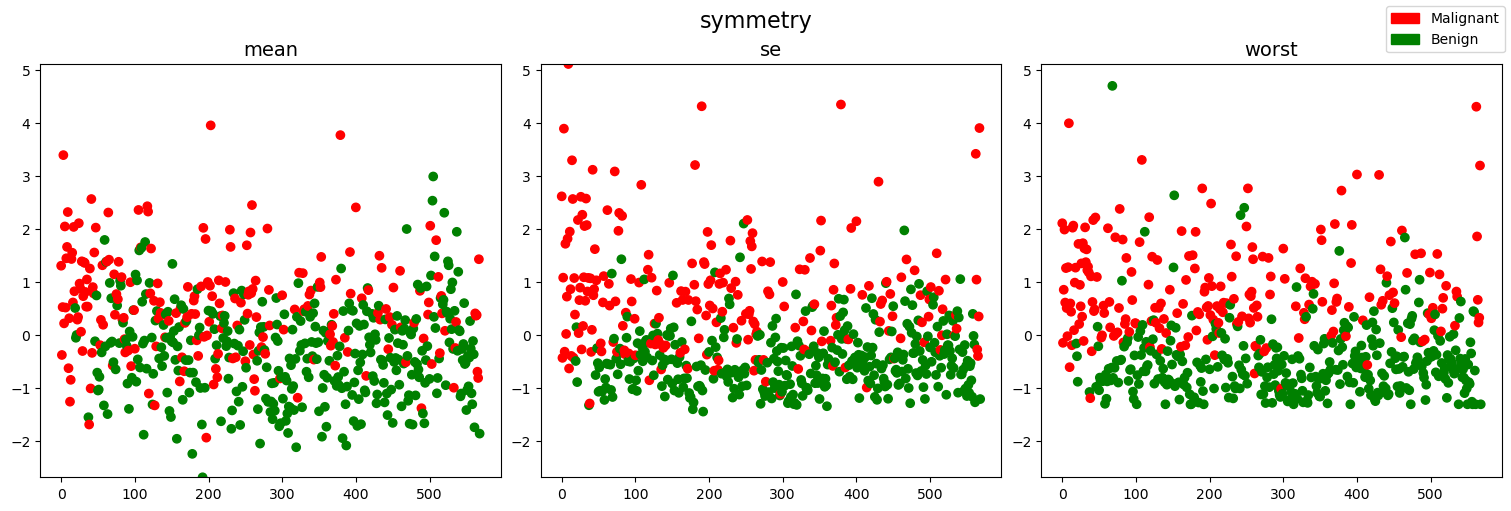

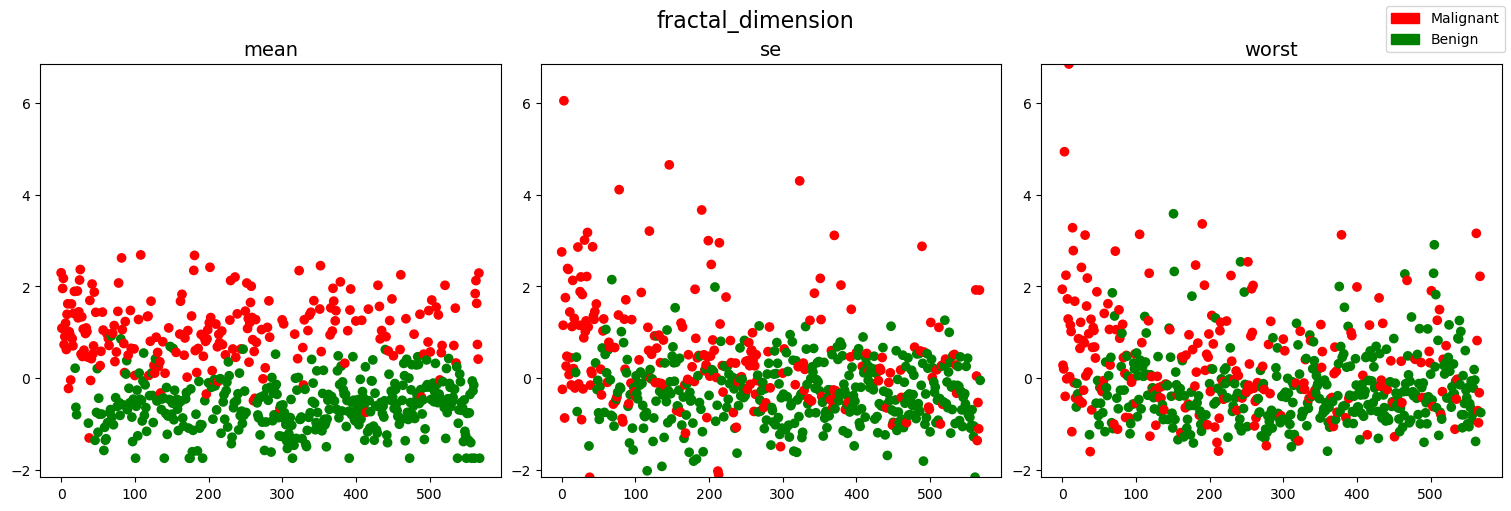

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

features = wibc_real.drop(columns=['id', 'class'])
labels = wibc_real['class']

scaler = StandardScaler()

pipeline = Pipeline([('standard_scaler', scaler)])

features_transform = pipeline.fit_transform(features)
df_transform = pd.DataFrame(features_transform, columns=attrib_names)
    
for c in attrib:
    i = -1
    lb = min([df_transform[f'{c}_{m}'].min() for m in metrics])
    ub = max([df_transform[f'{c}_{m}'].max() for m in metrics])
    
    fig, ax = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True)
    for cm in [f'{c}_{m}' for m in metrics]:
        i += 1
        ax[i].set_ylim(lb, ub)
        ax[i].scatter(df_transform.index, df_transform[cm], c=colors)
        ax[i].set_title(metrics[i], fontsize=14)
        
    fig.suptitle(c, fontsize=16)
    
    red_patch = mpatches.Patch(color='red', label='Malignant')
    green_patch = mpatches.Patch(color='green', label='Benign')
    fig.legend(handles=[red_patch, green_patch])

To ensure that we are not over-fitting our model, we must test it's predictive accuracy using different observations than those we used to train the model. We'll use train_test_split to partition our dataset into training and testing datasets. We should *never* evaluate our model using the same data with which we fit the model. Therefore, it is absolutely necessary to use some of the data as a *test* or *validation* or *holdout* sample (3 terms used to describe the same thing).

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

train_set, test_set, train_labels, test_labels = train_test_split(features, labels, train_size=0.6, random_state=42)

scaler = StandardScaler()
scaler.fit(features)

pipeline = Pipeline([('standard_scaler', scaler)])

features_transform = pipeline.fit_transform(train_set)
df_transform = pd.DataFrame(features_transform, columns=attrib_names)
df_transform.insert(0, 'class', labels)

print(df_transform.head())

  class  radius_mean  radius_se  radius_worst  texture_mean  texture_se  \
0     M    -0.931583  -1.585384     -0.960826     -0.827699   -0.803580   
1     M    -0.559847   0.739563     -0.595486     -0.549443   -1.040033   
2     M    -0.421139  -0.583053     -0.420495     -0.475549    1.177979   
3     M     0.086530  -1.283532      0.055578     -0.028932    0.149483   
4     M    -0.554298   2.474633     -0.626201     -0.552421   -1.397613   

   texture_worst  perimeter_mean  perimeter_se  perimeter_worst  ...  \
0      -1.108993       -0.976708     -0.936437        -1.315974  ...   
1      -1.016226       -0.917061     -0.964627        -0.961068  ...   
2       0.139978       -0.646779     -0.512026         1.190784  ...   
3      -0.296165       -0.104966     -0.158611        -0.232576  ...   
4      -1.365217       -1.130941     -1.293768        -0.374539  ...   

   concavity_worst  concave_points_mean  concave_points_se  \
0        -1.034474            -1.750326          -1.06

The code below calculates the distribution of observations by class in the complete dataset.

In [14]:
wibc_real['class'].value_counts() / len(wibc_real)

class
B    0.627417
M    0.372583
Name: count, dtype: float64

The data is unbalanced, with there being nearly twice as many benign as malignant samples. Were we fitting a real model, we'd want to select our training and testing samples using a stratified splitter, to ensure the proportion of benign and malignant tumors in the training and testing samples matched those in the general population.


Now let's *fit* a logistic regression classifier. After building our model (the call to clf.fit on line 20), we use the model to make a diagnoses for every tumor in the testing sample and calculate an accuracy score (accuracy is the % of correct diagnoses).

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

le = LabelEncoder()
le.fit(wibc_real['class'].unique())
malignant = le.transform(wibc_real['class'])


train_set, test_set, train_labels, test_labels = train_test_split(features, malignant, train_size=0.6, random_state=42)

scaler = StandardScaler()
clf = LogisticRegression()

pipeline = Pipeline([('standard_scaler', scaler)])

train_set_tran = pipeline.fit_transform(train_set)
test_set_tran = pipeline.transform(test_set)

clf.fit(X=train_set_tran, y=train_labels)
clf.score(test_set_tran, test_labels)


0.9824561403508771

As you can see from the above, our logistics regression model correctly diagnosed 98.2% of the tumors! There's a lot more to the story, but that's material for BUS 554 Applied Machine Learning!

Here we construct a side-by-side comparison of the predictions (i.e. the classifications) and the actual diagnosis. 

In [28]:
rslt = pd.DataFrame({'predicted': le.inverse_transform(clf.predict(test_set_tran)),
                     'actual': le.inverse_transform(test_labels)})

print(rslt.head(10))

  predicted actual
0         B      B
1         M      M
2         M      M
3         B      B
4         B      B
5         M      M
6         M      M
7         M      M
8         B      B
9         B      B


These diagnoses seem very cut and dried. However, our logistic regression model allows us to do one even better; we can add our model's prediction of the probabilities of being benign and malignant. 

In [29]:
pd.set_option('display.precision', 4)
pd.options.display.float_format = '{:0.4f}'.format
proba = clf.predict_proba(test_set_tran)
rslt = pd.DataFrame({'predicted': le.inverse_transform(clf.predict(test_set_tran)),
                     'actual': le.inverse_transform(test_labels),
                     'prob.benign': proba[:, 0],
                     'prob.malignant': proba[:, 1]})

print(rslt.head(10))

  predicted actual  prob.benign  prob.malignant
0         B      B       0.8606          0.1394
1         M      M       0.0000          1.0000
2         M      M       0.0045          0.9955
3         B      B       0.9992          0.0008
4         B      B       0.9999          0.0001
5         M      M       0.0000          1.0000
6         M      M       0.0000          1.0000
7         M      M       0.0513          0.9487
8         B      B       0.5538          0.4462
9         B      B       0.9987          0.0013


As we can see, the probabilities tell a different story. For example, look at observation 8. The tumor is classified as benign, but the model estimates a 44.6% chance that it is malignant. These probability predictions are even more relevant for planning/choosing treatment options than the classification (diagnosis)!

 We can also calculate the percentage of incorrect predictions/classifications. A table of conditional probabilities may be the most useful way to evaluate the model performed. You can read the following as probability of *predicted* given *actual*, e.g., probability of a benign prediction given a malignant tumor.

In [17]:
tab = pd.crosstab(rslt['actual'], rslt['predicted'], normalize='index')
tab.rename(columns={'B': 'Predicted.Benign', 'M': 'Predicted.Malignant'}, inplace=True)
tab.index = ['Actual.Benign', 'Actual.Malignant']
tab.index.name = 'actual'
tab

predicted,Predicted.Benign,Predicted.Malignant
actual,,
Actual.Benign,0.97973,0.02027
Actual.Malignant,0.01250,0.98750


# Logistic Regression

When we performed least squares regression, we built a predictive model for a continuous variable (e.g., sales, costs, etc.). In a logistic regression, we build a predictive model for a *binary outcome*. In our example, a tumor is either Benign (0) or Malignant (1); our two outcomes are denoted by 0 (*not* the outcome of interest), and 1 (the outcome of interest).

Just as with a least squares regression, we know the form of the model we are trying to construct. And, like the least squares regression, we solve an optimization problem to find the values of the decision variables (the independent variable coefficients in the model). Here's the model we fit in logistic regression:

$$\log \left( \frac{Pr\{y=1\}}{1-Pr\{y=1\}} \right)  = \beta_0 + \beta_1 x_1 + ... + \beta_n x_n$$

Comparing this to the least squares regression model (below), we see that the only difference is for the LHS (i.e., the *labels*). In the logistic regression model, the LHS is referred to as the *log odds* of the event.

$$\hat{y}  = \beta_0 + \beta_1 x_1 + ... + \beta_n x_n$$

## Calculating probabilities

That *log odds* LHS doesn't look like a nice simple probability, and it's not. However, we can use our logistic regression model to *calculate* $p=Pr\{y = 1\}$ (i.e., the probability of the event of interest); the probability of the other event is simply $1 - p$:

$$Pr\{y=1\} = \frac{e^{\beta_0 + \beta_1 x_1 + ... + \beta_n x_n}}{1+e^{\beta_0 + \beta_1 x_1 + ... + \beta_n x_n}}$$

## Classifying observations

Once we have our model, making a classification is easy. We simply calculate the probability and compare it to a threshold value (e.g. 0.5). If the probability exceeds the threshold, then the classification the *event of interest*, otherwise it is classified as the *other outcome*. In the case of our model, $p > 0.5 \rightarrow malignant$, $p \leq 0.5 \rightarrow benign$. 0.5 is a typical threshold value, but other values may be more appropriate for some cases.